# EDA Notebook for `cleaned_sentence_level.csv` and `NER_raw.csv`

This notebook:
- loads both datasets automatically
- applies the requested global plotting style
- generates all core EDA tables and figures
- saves every figure to `notebooks/figures/`
- exports important summary tables for reporting

**Main required outputs included:**
1. Sentence length distribution  
2. Entity length distribution  
3. Top entity types (cleaned / filtered)  
4. Class imbalance ratio table  
5. Before vs after balancing comparison

In [30]:
# ==============================
# 1. Imports, config, plot style
# ==============================
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

# ---- Global Plot Style ----
sns.set_theme(style="whitegrid")
PALETTE = "pastel"
FIG_DPI = 150

sns.set_palette(PALETTE)  

plt.rcParams.update({
    "figure.dpi"      : FIG_DPI,
    "axes.titlesize"  : 14,
    "axes.labelsize"  : 12,
    "xtick.labelsize" : 10,
    "ytick.labelsize" : 10,
    "legend.fontsize" : 10,
})

# ---- Project Paths (Stable for local repo) ----
PROJECT_ROOT = Path.cwd().resolve()

# climb up until we find "data" folder (or any known root marker)
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

FIG_DIR = PROJECT_ROOT / "notebooks" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Figure output directory:", FIG_DIR)

Project root: C:\Users\lynny\OneDrive\Desktop\uni\year 4\winter2026\st DSAI4201 selected topics\project\code\smart-document-redaction
Figure output directory: C:\Users\lynny\OneDrive\Desktop\uni\year 4\winter2026\st DSAI4201 selected topics\project\code\smart-document-redaction\notebooks\figures


In [31]:
# ======================================
# 2. Helpers: file discovery + utilities
# ======================================
def find_file(filename: str):
    candidates = [
        Path(filename),
        PROJECT_ROOT / filename,
        PROJECT_ROOT / "data" / filename,
        PROJECT_ROOT / "datasets" / filename,
        PROJECT_ROOT / "notebooks" / filename,
        Path("/content") / filename,
        Path("/content") / "data" / filename,
        Path("/mnt/data") / filename,
    ]
    for path in candidates:
        if path.exists():
            return path

    for search_root in [PROJECT_ROOT, Path("/content"), Path("/mnt/data")]:
        if search_root.exists():
            found = list(search_root.rglob(filename))
            if found:
                return found[0]
    raise FileNotFoundError(f"Could not locate {filename!r}. Place it in the project folder and rerun.")


def savefig(name: str, tight: bool = True):
    path = FIG_DIR / name
    if tight:
        plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    print(f"Saved: {path}")

In [32]:
# =====================
# 3. Load input datasets
# =====================

# ---- Define paths (FIXED) ----
RAW_PATH = Path("../data/raw/NER_raw.csv").resolve()
CLEANED_PATH = Path("../data/processed/cleaned_sentence_level.csv").resolve()

# ---- Check existence ----
assert RAW_PATH.exists(), f"File not found: {RAW_PATH}"
assert CLEANED_PATH.exists(), f"File not found: {CLEANED_PATH}"

print("NER_raw.csv ->", RAW_PATH)
print("cleaned_sentence_level.csv ->", CLEANED_PATH)

# ---- Load datasets ----
raw_df = pd.read_csv(RAW_PATH, encoding="latin1")
cleaned_df = pd.read_csv(CLEANED_PATH)

# ---- Basic info ----
print("Raw shape:", raw_df.shape)
print("Cleaned shape:", cleaned_df.shape)

display(raw_df.head())
display(cleaned_df.head())

NER_raw.csv -> C:\Users\lynny\OneDrive\Desktop\uni\year 4\winter2026\st DSAI4201 selected topics\project\code\smart-document-redaction\data\raw\NER_raw.csv
cleaned_sentence_level.csv -> C:\Users\lynny\OneDrive\Desktop\uni\year 4\winter2026\st DSAI4201 selected topics\project\code\smart-document-redaction\data\processed\cleaned_sentence_level.csv
Raw shape: (1048575, 4)
Cleaned shape: (697076, 6)


,Sentence #,Word,POS,Tag
0,Sentence: 1,Thousands,NNS,O
1,NaN,of,IN,O
2,NaN,demonstrators,NNS,O
3,NaN,have,VBP,O
4,NaN,marched,VBN,O


,example_id,text,entity_text,label,start,end
0,1,Thousands of demonstrators have marched through London to protest the war in Iraq and demand the withdrawal of British troops from that country.,London,LOCATION,48,54
1,1,Thousands of demonstrators have marched through London to protest the war in Iraq and demand the withdrawal of British troops from that country.,Iraq,LOCATION,77,81
2,1,Thousands of demonstrators have marched through London to protest the war in Iraq and demand the withdrawal of British troops from that country.,British,LOCATION,111,118
3,2,thousands of demonstrators have marched through london to protest the war in iraq and demand the withdrawal of british troops from that country.,london,LOCATION,48,54
4,2,thousands of demonstrators have marched through london to protest the war in iraq and demand the withdrawal of british troops from that country.,iraq,LOCATION,77,81


In [33]:
# ==========================================
# 4. Standardize columns and normalize labels
# ==========================================
raw_df.columns = [str(c).strip() for c in raw_df.columns]
cleaned_df.columns = [str(c).strip() for c in cleaned_df.columns]

raw_col_map = {}
for c in raw_df.columns:
    c_low = c.lower().strip()
    if c_low.startswith("sentence"):
        raw_col_map["sentence"] = c
    elif c_low == "word":
        raw_col_map["word"] = c
    elif c_low == "pos":
        raw_col_map["pos"] = c
    elif c_low == "tag":
        raw_col_map["tag"] = c

required_raw = {"sentence", "word", "tag"}
missing_raw = required_raw - set(raw_col_map)
if missing_raw:
    raise ValueError(f"Missing expected raw columns: {missing_raw}. Found: {raw_df.columns.tolist()}")

rename_map = {
    raw_col_map["sentence"]: "Sentence #",
    raw_col_map["word"]: "Word",
    raw_col_map["tag"]: "Tag",
}
if "pos" in raw_col_map:
    rename_map[raw_col_map["pos"]] = "POS"
raw_df = raw_df.rename(columns=rename_map)
if "POS" not in raw_df.columns:
    raw_df["POS"] = "UNK"

rename_clean = {}
for c in cleaned_df.columns:
    c_low = c.lower().strip()
    if c_low in ["text", "sentence", "sentence_text"]:
        rename_clean[c] = "text"
    elif c_low in ["entity_text", "entity", "span_text"]:
        rename_clean[c] = "entity_text"
    elif c_low in ["label", "entity_label", "entity_type", "tag"]:
        rename_clean[c] = "label"
    elif c_low == "start":
        rename_clean[c] = "start"
    elif c_low == "end":
        rename_clean[c] = "end"
    elif c_low in ["example_id", "sentence_id", "id"]:
        rename_clean[c] = "example_id"
cleaned_df = cleaned_df.rename(columns=rename_clean)

for col in ["text", "entity_text", "label"]:
    if col not in cleaned_df.columns:
        cleaned_df[col] = np.nan

raw_df["Word"] = raw_df["Word"].astype(str).str.replace("​", "", regex=False).str.strip()
raw_df["Tag"] = raw_df["Tag"].astype(str).str.strip().str.upper()
raw_df["POS"] = raw_df["POS"].astype(str).str.strip().str.upper()
raw_df = raw_df[raw_df["Word"].ne("")].copy()
raw_df["Sentence #"] = raw_df["Sentence #"].astype(str).replace({"nan": np.nan}).ffill()
raw_df["sentence_id"] = (
    raw_df["Sentence #"].astype(str)
    .str.extract(r"(\d+)", expand=False)
    .astype(float)
    .ffill()
    .astype(int)
)

LABEL_MAP = {
    "PER": "PERSON",
    "ORG": "ORGANIZATION",
    "GEO": "LOCATION",
    "GPE": "GPE",
    "LOC": "LOCATION",
    "TIM": "TIME",
    "TIME": "TIME",
    "DATE": "DATE",
    "ART": "MISC",
    "EVE": "MISC",
    "NAT": "MISC",
}

KEEP_LABELS = [
    "PERSON", "ORGANIZATION", "LOCATION", "GPE", "DATE", "TIME",
    "MISC", "MONEY", "PERCENT", "FACILITY", "EMAIL", "PHONE", "ID",
    "PASSPORT", "CREDIT_CARD", "ADDRESS", "URL_TOKEN", "IP_ADDRESS"
]


def split_bio_tag(tag: str):
    tag = str(tag).strip().upper()
    if tag in ["", "O", "NAN"]:
        return "O", "O"
    if "-" in tag:
        bio, ent = tag.split("-", 1)
    else:
        bio, ent = "B", tag
    ent = LABEL_MAP.get(ent.upper(), ent.upper())
    return bio, ent

raw_df[["bio", "entity_type"]] = raw_df["Tag"].apply(lambda x: pd.Series(split_bio_tag(x)))
cleaned_df["label"] = cleaned_df["label"].astype(str).str.strip().str.upper().replace(LABEL_MAP)

print("Normalized raw columns:", raw_df.columns.tolist())
print("Normalized cleaned columns:", cleaned_df.columns.tolist())

Normalized raw columns: ['Sentence #', 'Word', 'POS', 'Tag', 'sentence_id', 'bio', 'entity_type']
Normalized cleaned columns: ['example_id', 'text', 'entity_text', 'label', 'start', 'end']


In [34]:
# =========================================
# 5. Rebuild sentence texts from raw dataset
# =========================================
def join_tokens(tokens):
    text = " ".join([str(t) for t in tokens if pd.notna(t)]).strip()
    text = re.sub(r"\s+([,.;:!?%\)])", r"", text)
    text = re.sub(r"([\(\[\{])\s+", r"", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

sentence_df_raw = (
    raw_df.groupby("sentence_id", sort=True)
          .agg(
              sentence_text=("Word", lambda x: join_tokens(x.tolist())),
              n_tokens=("Word", "size"),
              n_entity_tokens=("entity_type", lambda x: (x != "O").sum()),
          )
          .reset_index()
)
sentence_df_raw["char_length"] = sentence_df_raw["sentence_text"].str.len()
sentence_df_raw["word_length"] = sentence_df_raw["sentence_text"].str.split().str.len()

display(sentence_df_raw.head())
print("Sentence-level raw shape:", sentence_df_raw.shape)

,sentence_id,sentence_text,n_tokens,n_entity_tokens,char_length,word_length
0,1,Thousands of demonstrators have marched through London to protest the war in Iraq and demand the withdrawal of British troops from that country,24,3,144,23
1,2,"Families of soldiers killed in the conflict joined the protesters who carried banners with such slogans as "" Bush Number One Terrorist "" and "" Stop the Bombings """,30,1,163,29
2,3,They marched from the Houses of Parliament to a rally in Hyde Park,14,2,67,13
3,4,"Police put the number of marchers at 10,000 while organizers claimed it was 1,00,000",15,0,85,14
4,5,The protest comes on the eve of the annual conference of Britain 's ruling Labor Party in the southern English seaside resort of Brighton,25,5,138,24


Sentence-level raw shape: (47959, 6)


In [35]:
# ==========================================================
# 6. Prepare cleaned sentence-level views and entity-level view
# ==========================================================
if "text" not in cleaned_df.columns:
    raise ValueError("Could not find a sentence text column in cleaned_sentence_level.csv")

sentence_df_clean = cleaned_df[[c for c in cleaned_df.columns if c in ["example_id", "text"]]].drop_duplicates().copy()
if sentence_df_clean.empty:
    sentence_df_clean = pd.DataFrame({"text": cleaned_df["text"].dropna().unique()})

sentence_df_clean["char_length"] = sentence_df_clean["text"].astype(str).str.len()
sentence_df_clean["word_length"] = sentence_df_clean["text"].astype(str).str.split().str.len()

entity_df = cleaned_df.copy()
entity_df = entity_df[entity_df["entity_text"].notna() & entity_df["label"].notna()].copy()
entity_df = entity_df[entity_df["label"].ne("NAN")].copy()
entity_df["entity_text"] = entity_df["entity_text"].astype(str)
entity_df["entity_token_length"] = entity_df["entity_text"].str.split().str.len()
entity_df["entity_char_length"] = entity_df["entity_text"].str.len()

print("Unique cleaned sentences:", len(sentence_df_clean))
print("Cleaned entity rows:", len(entity_df))
display(sentence_df_clean.head())
display(entity_df.head())

Unique cleaned sentences: 253302
Cleaned entity rows: 697076


,example_id,text,char_length,word_length
0,1,Thousands of demonstrators have marched through London to protest the war in Iraq and demand the withdrawal of British troops from that country.,144,23
3,2,thousands of demonstrators have marched through london to protest the war in iraq and demand the withdrawal of british troops from that country.,144,23
6,3,THOUSANDS OF DEMONSTRATORS HAVE MARCHED THROUGH LONDON TO PROTEST THE WAR IN IRAQ AND DEMAND THE WITHDRAWAL OF BRITISH TROOPS FROM THAT COUNTRY.,144,23
9,4,Thousands Of Demonstrators Have Marched Through London To Protest The War In Iraq And Demand The Withdrawal Of British Troops From That Country.,144,23
12,5,"Iranian officials say they expect to get access to sealed sensitive parts of the plant Wednesday, after an IAEA surveillance system begins functioning.",151,23


,example_id,text,entity_text,label,start,end,entity_token_length,entity_char_length
0,1,Thousands of demonstrators have marched through London to protest the war in Iraq and demand the withdrawal of British troops from that country.,London,LOCATION,48,54,1,6
1,1,Thousands of demonstrators have marched through London to protest the war in Iraq and demand the withdrawal of British troops from that country.,Iraq,LOCATION,77,81,1,4
2,1,Thousands of demonstrators have marched through London to protest the war in Iraq and demand the withdrawal of British troops from that country.,British,LOCATION,111,118,1,7
3,2,thousands of demonstrators have marched through london to protest the war in iraq and demand the withdrawal of british troops from that country.,london,LOCATION,48,54,1,6
4,2,thousands of demonstrators have marched through london to protest the war in iraq and demand the withdrawal of british troops from that country.,iraq,LOCATION,77,81,1,4


In [36]:
# ======================================
# 7. Quick dataset overview / key metrics
# ======================================
summary = {
    "raw_rows": len(raw_df),
    "raw_sentences": raw_df["sentence_id"].nunique(),
    "raw_unique_tags": raw_df["Tag"].nunique(),
    "cleaned_rows": len(cleaned_df),
    "cleaned_unique_sentences": sentence_df_clean["text"].nunique(),
    "cleaned_entities": len(entity_df),
    "cleaned_entity_labels": entity_df["label"].nunique(),
    "avg_sentence_len_tokens_raw": round(sentence_df_raw["n_tokens"].mean(), 2),
    "avg_sentence_len_tokens_clean": round(sentence_df_clean["word_length"].mean(), 2),
    "avg_entity_len_tokens_clean": round(entity_df["entity_token_length"].mean(), 2) if len(entity_df) else np.nan,
}
summary_df = pd.DataFrame(summary.items(), columns=["metric", "value"])
display(summary_df)
summary_df.to_csv(FIG_DIR / "dataset_summary.csv", index=False)

,metric,value
0,raw_rows,1048571.00
1,raw_sentences,47959.00
2,raw_unique_tags,17.00
3,cleaned_rows,697076.00
4,cleaned_unique_sentences,174959.00
5,cleaned_entities,697076.00
6,cleaned_entity_labels,14.00
7,avg_sentence_len_tokens_raw,21.86
8,avg_sentence_len_tokens_clean,19.60
9,avg_entity_len_tokens_clean,1.45


## Required Visualization 1 — Sentence Length Distribution

Saved: C:\Users\lynny\OneDrive\Desktop\uni\year 4\winter2026\st DSAI4201 selected topics\project\code\smart-document-redaction\notebooks\figures\sentence_length_distribution_cleaned.png


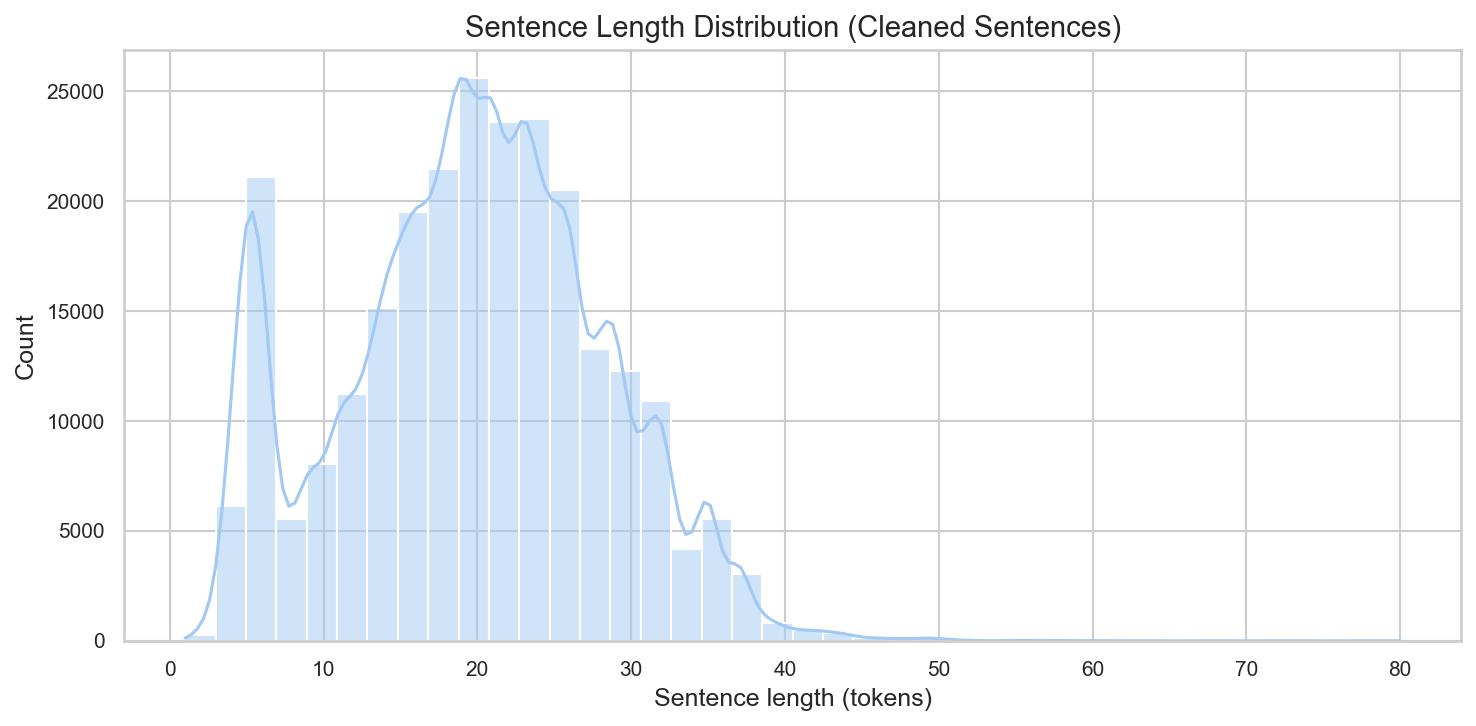

Saved: C:\Users\lynny\OneDrive\Desktop\uni\year 4\winter2026\st DSAI4201 selected topics\project\code\smart-document-redaction\notebooks\figures\sentence_length_boxplot_cleaned.png


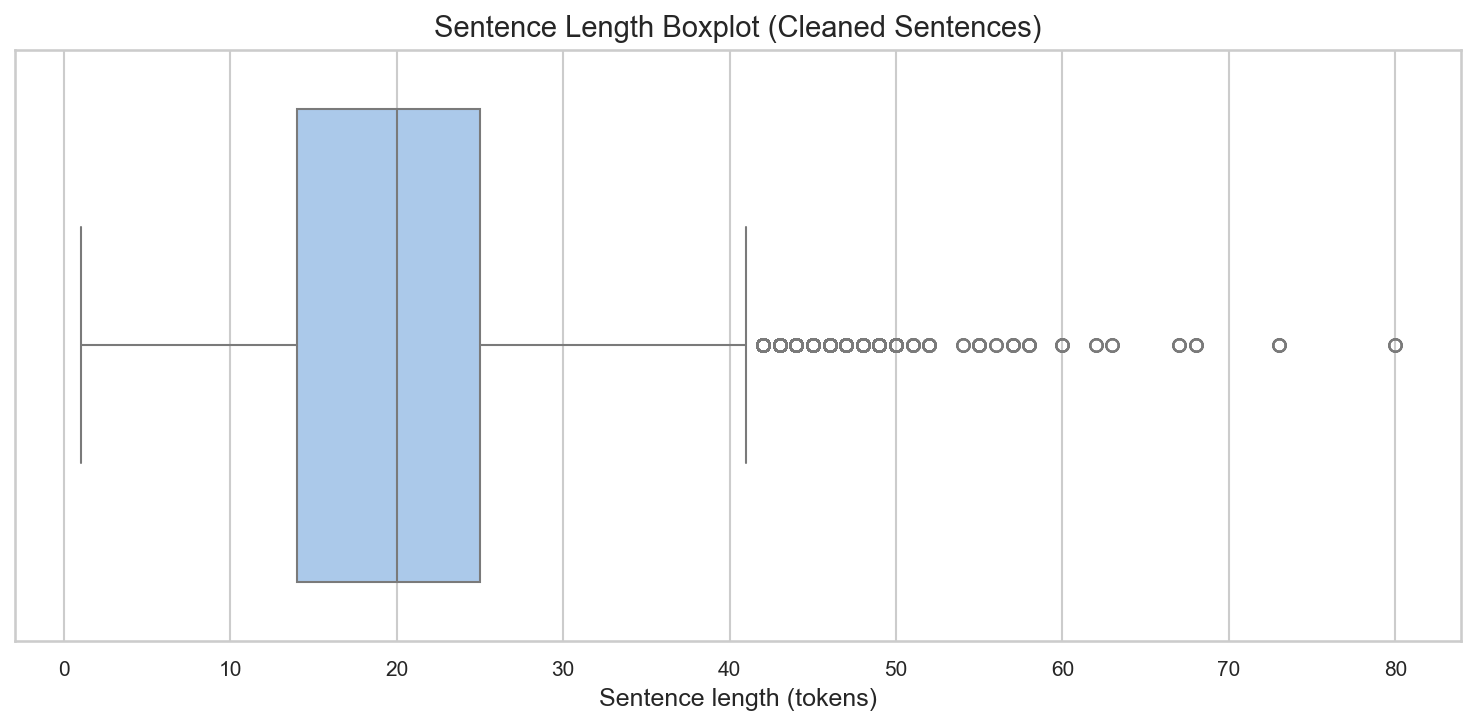

,value
count,253302.000000
mean,19.599293
std,8.486442
min,1.000000
25%,14.000000
50%,20.000000
75%,25.000000
90%,31.000000
95%,33.000000
99%,38.000000


In [37]:
# =====================================
# 8. Sentence length distribution plots
# =====================================
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(sentence_df_clean["word_length"], bins=40, kde=True, ax=ax)
ax.set_title("Sentence Length Distribution (Cleaned Sentences)")
ax.set_xlabel("Sentence length (tokens)")
ax.set_ylabel("Count")
savefig("sentence_length_distribution_cleaned.png")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(x=sentence_df_clean["word_length"], ax=ax)
ax.set_title("Sentence Length Boxplot (Cleaned Sentences)")
ax.set_xlabel("Sentence length (tokens)")
savefig("sentence_length_boxplot_cleaned.png")
plt.show()

sentence_length_stats = sentence_df_clean["word_length"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame("value")
display(sentence_length_stats)
sentence_length_stats.to_csv(FIG_DIR / "sentence_length_summary.csv")

## Required Visualization 2 — Entity Length Distribution

Saved: C:\Users\lynny\OneDrive\Desktop\uni\year 4\winter2026\st DSAI4201 selected topics\project\code\smart-document-redaction\notebooks\figures\entity_length_distribution_tokens.png


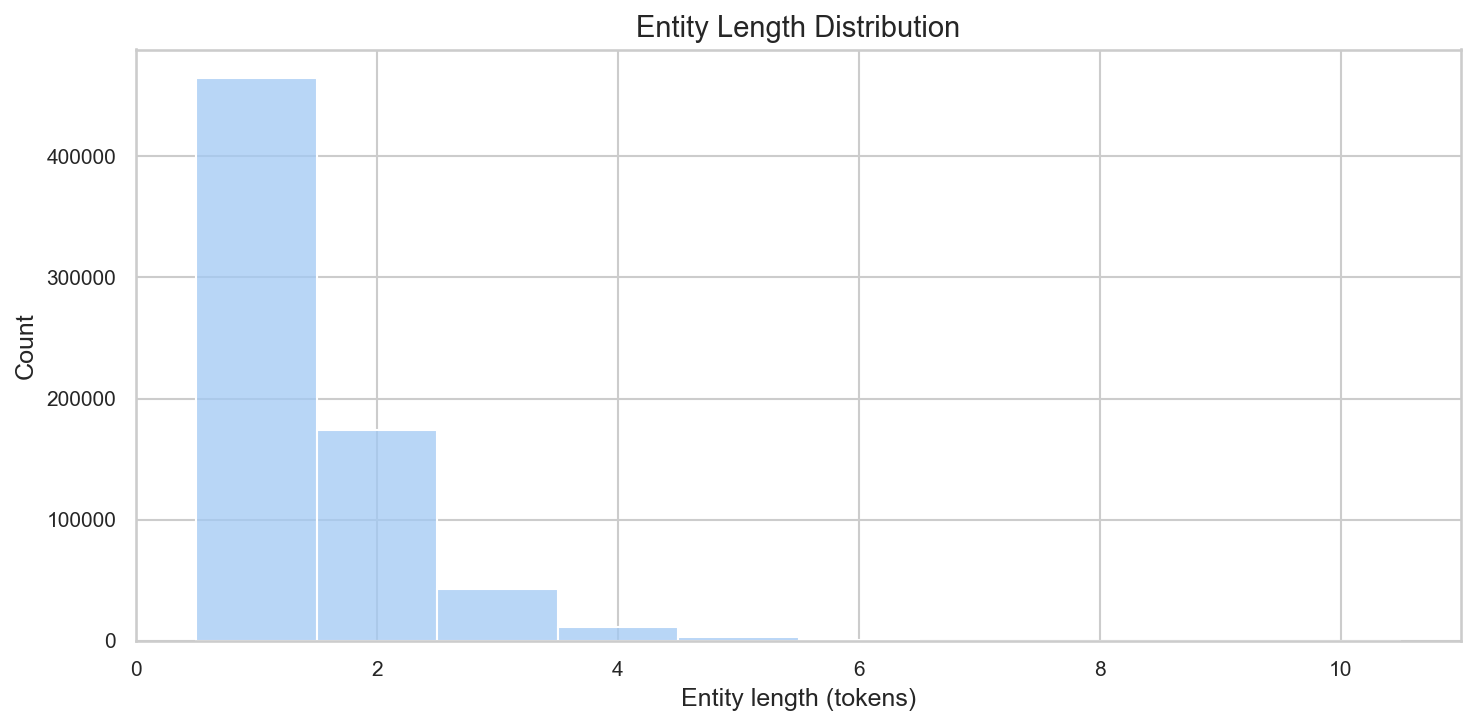

,entity_token_length,count,percentage
0,1,464943,66.699040
1,2,173832,24.937310
2,3,42784,6.137638
3,4,11231,1.611159
4,5,3034,0.435247
5,6,890,0.127676
6,7,267,0.038303
7,8,75,0.010759
8,9,16,0.002295
9,10,4,0.000574


In [38]:
# ====================================
# 9. Entity length distribution plots
# ====================================
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(entity_df["entity_token_length"], bins=range(1, int(entity_df["entity_token_length"].max()) + 2), discrete=True, ax=ax)
ax.set_title("Entity Length Distribution")
ax.set_xlabel("Entity length (tokens)")
ax.set_ylabel("Count")
savefig("entity_length_distribution_tokens.png")
plt.show()

entity_len_counts = (
    entity_df["entity_token_length"].value_counts().sort_index().rename_axis("entity_token_length").reset_index(name="count")
)
entity_len_counts["percentage"] = 100 * entity_len_counts["count"] / entity_len_counts["count"].sum()
display(entity_len_counts.head(20))
entity_len_counts.to_csv(FIG_DIR / "entity_length_distribution_table.csv", index=False)

## Required Visualization 3 — Top Entity Types (Cleaned / Filtered)

,label,count,percentage
0,LOCATION,281956,40.448387
1,PERSON,129591,18.590656
2,DATE,120099,17.228968
3,ORGANIZATION,111897,16.052339
4,TIME,53268,7.641634
5,EMAIL,30,0.004304
6,PHONE,30,0.004304
7,CREDIT_CARD,30,0.004304
8,IP_ADDRESS,30,0.004304
9,MONEY,30,0.004304


Saved: C:\Users\lynny\OneDrive\Desktop\uni\year 4\winter2026\st DSAI4201 selected topics\project\code\smart-document-redaction\notebooks\figures\top_entity_types_cleaned.png


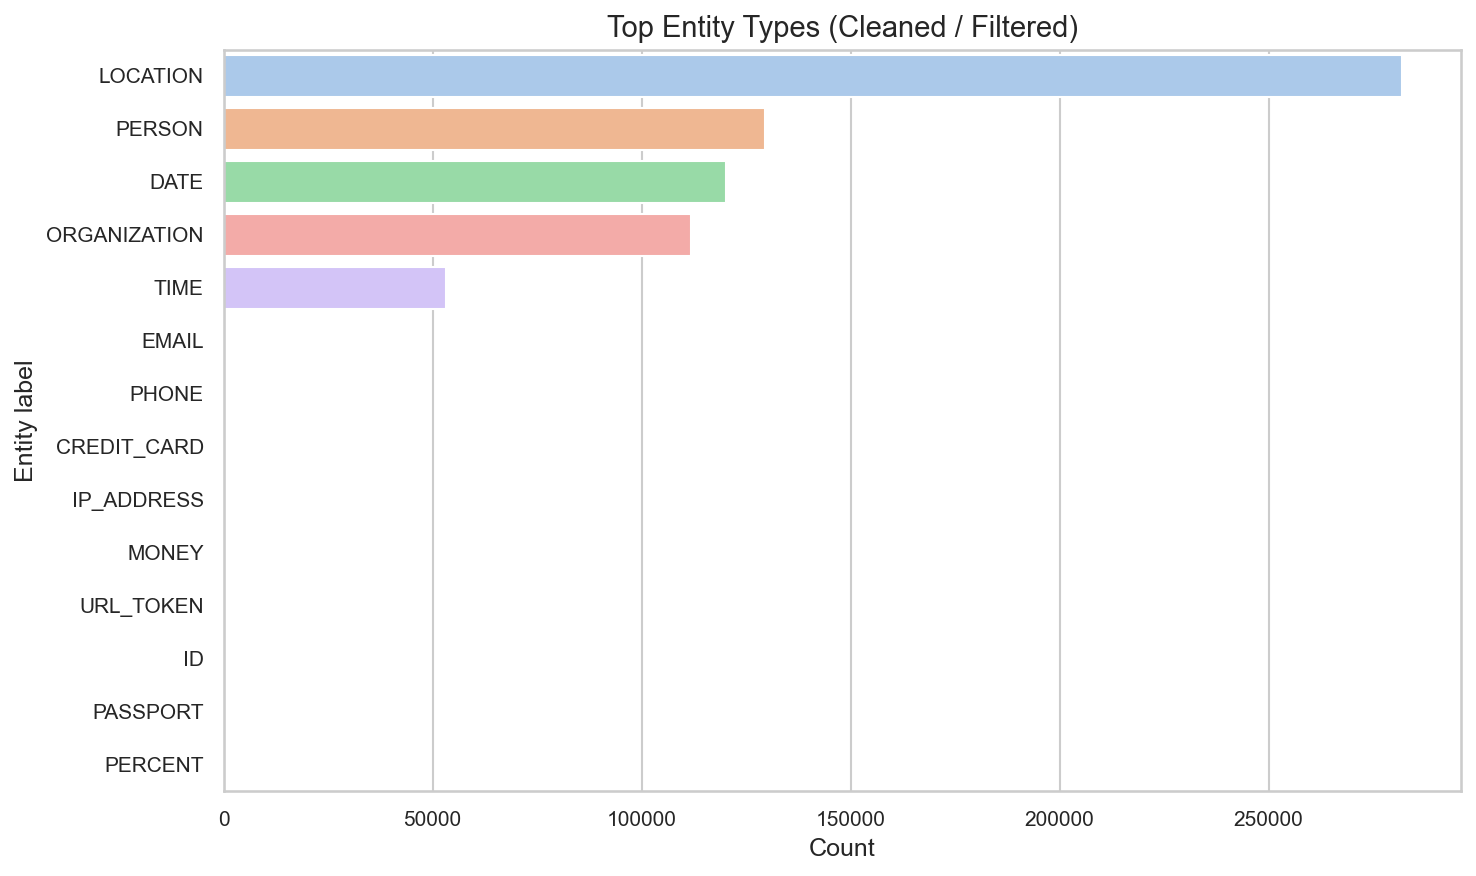

In [39]:
# ============================================
# 10. Top entity types (cleaned / filtered set)
# ============================================
filtered_entity_df = entity_df[entity_df["label"].isin(KEEP_LABELS)].copy()
label_counts_clean = filtered_entity_df["label"].value_counts().rename_axis("label").reset_index(name="count")
label_counts_clean["percentage"] = 100 * label_counts_clean["count"] / label_counts_clean["count"].sum()

display(label_counts_clean)
label_counts_clean.to_csv(FIG_DIR / "cleaned_entity_type_distribution.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=label_counts_clean, y="label", x="count", palette=PALETTE, ax=ax)
ax.set_title("Top Entity Types (Cleaned / Filtered)")
ax.set_xlabel("Count")
ax.set_ylabel("Entity label")
savefig("top_entity_types_cleaned.png")
plt.show()

## Required Output 4 — Class Imbalance Ratio Table

In [40]:
# ====================================
# 11. Class imbalance ratio summary
# ====================================
class_imbalance_df = raw_df["entity_type"].value_counts(dropna=False).rename_axis("Label").reset_index(name="Count")
class_imbalance_df["Percentage"] = 100 * class_imbalance_df["Count"] / class_imbalance_df["Count"].sum()
class_imbalance_df["Percentage"] = class_imbalance_df["Percentage"].round(2)

display(class_imbalance_df)
class_imbalance_df.to_csv(FIG_DIR / "class_imbalance_ratio_table.csv", index=False)

latex_ready = class_imbalance_df.copy()
latex_ready["Percentage"] = latex_ready["Percentage"].map(lambda x: f"{x:.2f}\%")
print(latex_ready.to_latex(index=False, caption="Entity Distribution Summary", label="tab:entity_distribution_summary"))

,Label,Count,Percentage
0,O,887904,84.68
1,LOCATION,45058,4.30
2,ORGANIZATION,36927,3.52
3,PERSON,34241,3.27
4,TIME,26861,2.56
5,GPE,16068,1.53
6,MISC,1512,0.14


\begin{table}
\caption{Entity Distribution Summary}
\label{tab:entity_distribution_summary}
\begin{tabular}{lrl}
\toprule
Label & Count & Percentage \\
\midrule
O & 887904 & 84.68\% \\
LOCATION & 45058 & 4.30\% \\
ORGANIZATION & 36927 & 3.52\% \\
PERSON & 34241 & 3.27\% \\
TIME & 26861 & 2.56\% \\
GPE & 16068 & 1.53\% \\
MISC & 1512 & 0.14\% \\
\bottomrule
\end{tabular}
\end{table}



## Required Visualization 5 — Before vs After Balancing

,label,raw_count,cleaned_count,raw_pct,cleaned_pct
0,LOCATION,45058.0,281956.0,28.044340,40.448387
2,PERSON,34241.0,129591.0,21.311782,18.590656
6,DATE,0.0,120099.0,0.000000,17.228968
1,ORGANIZATION,36927.0,111897.0,22.983562,16.052339
3,TIME,26861.0,53268.0,16.718430,7.641634
7,EMAIL,0.0,30.0,0.000000,0.004304
9,CREDIT_CARD,0.0,30.0,0.000000,0.004304
8,PHONE,0.0,30.0,0.000000,0.004304
12,URL_TOKEN,0.0,30.0,0.000000,0.004304
13,ID,0.0,30.0,0.000000,0.004304


Saved: C:\Users\lynny\OneDrive\Desktop\uni\year 4\winter2026\st DSAI4201 selected topics\project\code\smart-document-redaction\notebooks\figures\before_vs_after_balancing.png


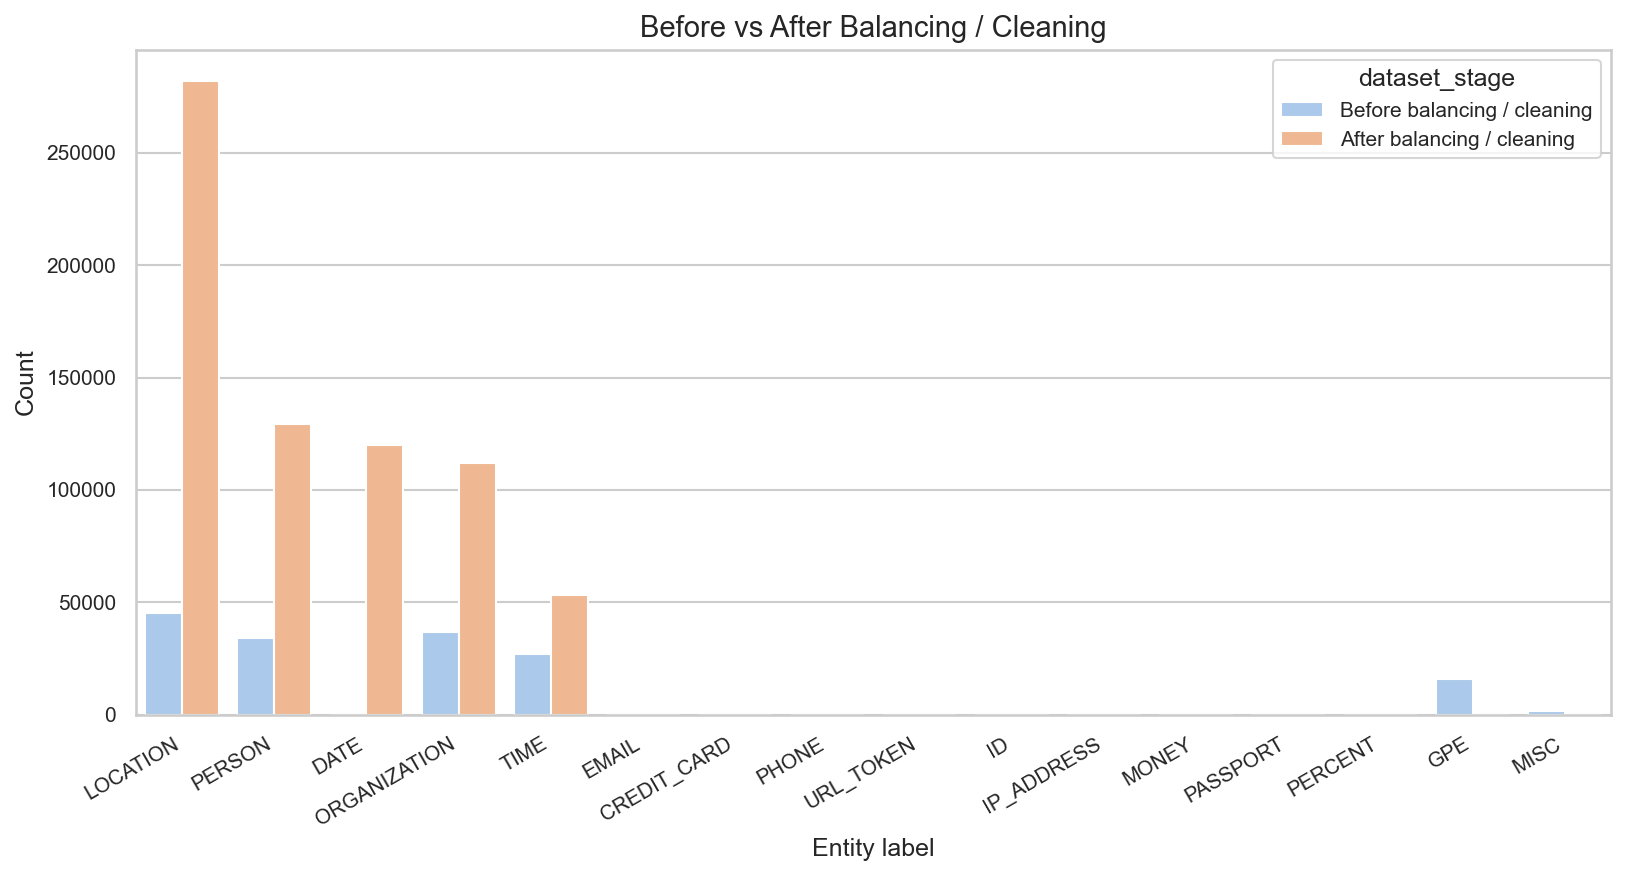

In [41]:
# ======================================
# 12. Before vs after balancing analysis
# ======================================
raw_entity_only = raw_df[raw_df["entity_type"] != "O"].copy()
raw_label_dist = raw_entity_only["entity_type"].value_counts().rename("raw_count")
clean_label_dist = filtered_entity_df["label"].value_counts().rename("cleaned_count")

before_after_df = pd.concat([raw_label_dist, clean_label_dist], axis=1).fillna(0)
before_after_df.index.name = "label"
before_after_df = before_after_df.reset_index()
before_after_df["raw_pct"] = 100 * before_after_df["raw_count"] / before_after_df["raw_count"].sum()
before_after_df["cleaned_pct"] = 100 * before_after_df["cleaned_count"] / before_after_df["cleaned_count"].sum()
before_after_df = before_after_df.sort_values("cleaned_count", ascending=False)

display(before_after_df)
before_after_df.to_csv(FIG_DIR / "before_vs_after_balancing_table.csv", index=False)

plot_df = before_after_df.melt(
    id_vars="label",
    value_vars=["raw_count", "cleaned_count"],
    var_name="dataset_stage",
    value_name="count"
)
plot_df["dataset_stage"] = plot_df["dataset_stage"].map({
    "raw_count": "Before balancing / cleaning",
    "cleaned_count": "After balancing / cleaning",
})

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=plot_df, x="label", y="count", hue="dataset_stage", palette=PALETTE, ax=ax)
ax.set_title("Before vs After Balancing / Cleaning")
ax.set_xlabel("Entity label")
ax.set_ylabel("Count")
plt.xticks(rotation=30, ha="right")
savefig("before_vs_after_balancing.png")
plt.show()

## Bonus Visualizations

,BIO,count
0,O,887904
1,B,111891
2,I,48776


Saved: C:\Users\lynny\OneDrive\Desktop\uni\year 4\winter2026\st DSAI4201 selected topics\project\code\smart-document-redaction\notebooks\figures\bio_prefix_distribution.png


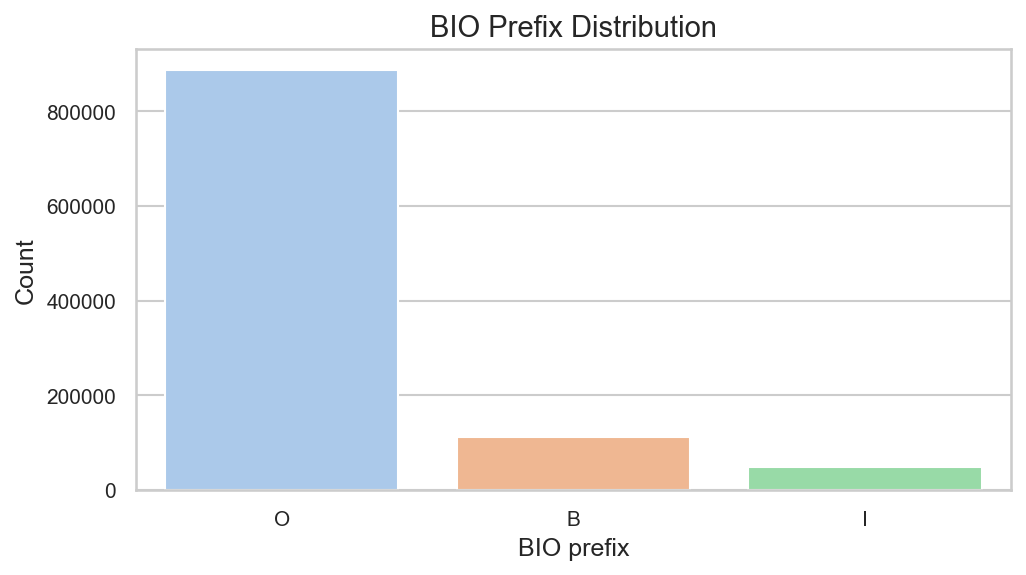

In [42]:
# =========================================
# 13. Token-level BIO prefix distribution
# =========================================
bio_dist = raw_df["bio"].value_counts().rename_axis("BIO").reset_index(name="count")
display(bio_dist)
bio_dist.to_csv(FIG_DIR / "bio_prefix_distribution.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=bio_dist, x="BIO", y="count", palette=PALETTE, ax=ax)
ax.set_title("BIO Prefix Distribution")
ax.set_xlabel("BIO prefix")
ax.set_ylabel("Count")
savefig("bio_prefix_distribution.png")
plt.show()

Saved: C:\Users\lynny\OneDrive\Desktop\uni\year 4\winter2026\st DSAI4201 selected topics\project\code\smart-document-redaction\notebooks\figures\entities_per_sentence.png


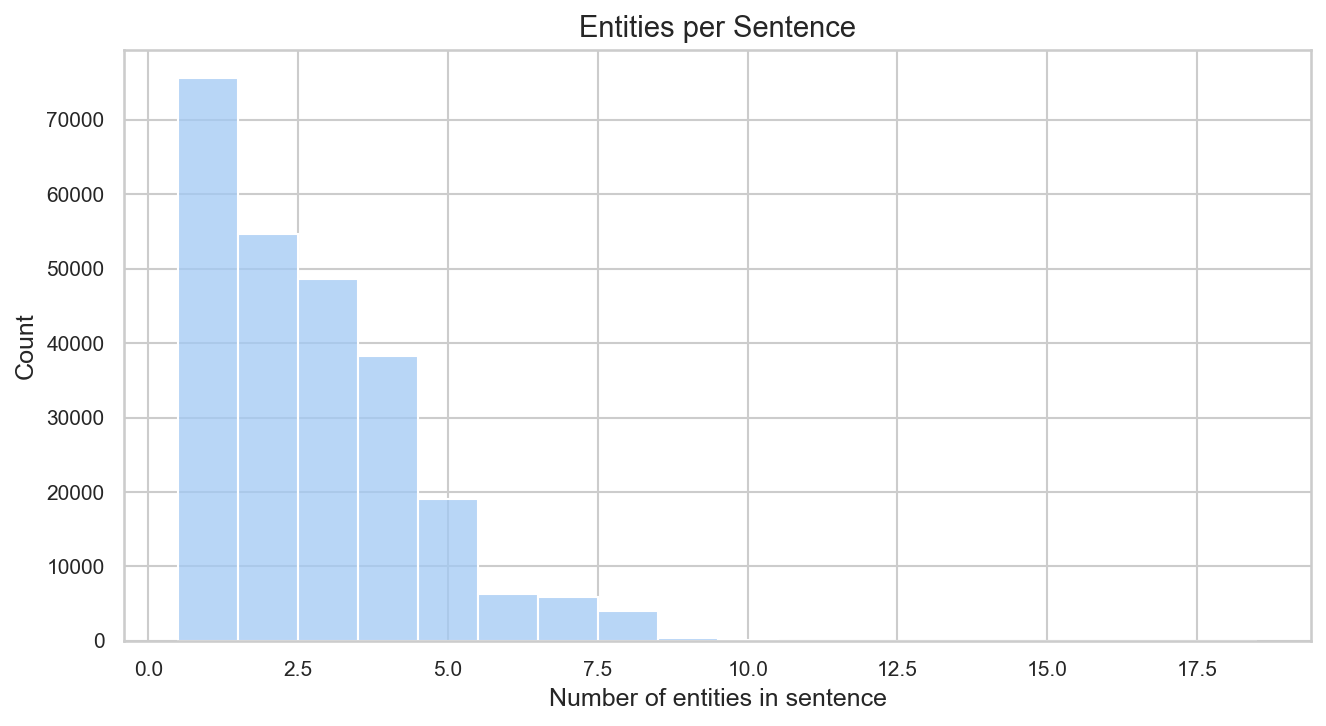

,value
count,253302.000000
mean,2.751956
std,1.706302
min,1.000000
25%,1.000000
50%,2.000000
75%,4.000000
max,18.000000


In [43]:
# =========================================
# 14. Sentences by number of entities present
# =========================================
if "example_id" in entity_df.columns:
    sent_entity_counts = entity_df.groupby("example_id").size().rename("entity_count").reset_index()
else:
    sent_entity_counts = entity_df.groupby("text").size().rename("entity_count").reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(sent_entity_counts["entity_count"], bins=range(1, sent_entity_counts["entity_count"].max() + 2), discrete=True, ax=ax)
ax.set_title("Entities per Sentence")
ax.set_xlabel("Number of entities in sentence")
ax.set_ylabel("Count")
savefig("entities_per_sentence.png")
plt.show()

sent_entity_counts.to_csv(FIG_DIR / "entities_per_sentence_table.csv", index=False)
display(sent_entity_counts["entity_count"].describe().to_frame("value"))

In [44]:
# ==================================
# 15. Top multi-token entities sample
# ==================================
multi_token_entities = (
    entity_df[entity_df["entity_token_length"] >= 2]
    .groupby(["label", "entity_text", "entity_token_length"])
    .size()
    .reset_index(name="count")
    .sort_values(["count", "entity_token_length"], ascending=[False, False])
)

display(multi_token_entities.head(25))
multi_token_entities.head(100).to_csv(FIG_DIR / "top_multitoken_entities.csv", index=False)

,label,entity_text,entity_token_length,count
11038,LOCATION,United States,2,2786
32916,PERSON,Mr. Abbas,2,2539
42279,TIME,10:30 AM,2,2057
42278,TIME,08:15 a.m.,2,2005
42280,TIME,12:00 PM,2,1997
42281,TIME,9 pm,2,1954
22093,ORGANIZATION,United Nations,2,1784
33066,PERSON,Mr. Fox,2,1586
430,DATE,1904 - 5,3,1580
11005,LOCATION,UNITED STATES,2,1402


Saved: C:\Users\lynny\OneDrive\Desktop\uni\year 4\winter2026\st DSAI4201 selected topics\project\code\smart-document-redaction\notebooks\figures\before_vs_after_balancing_percentage.png


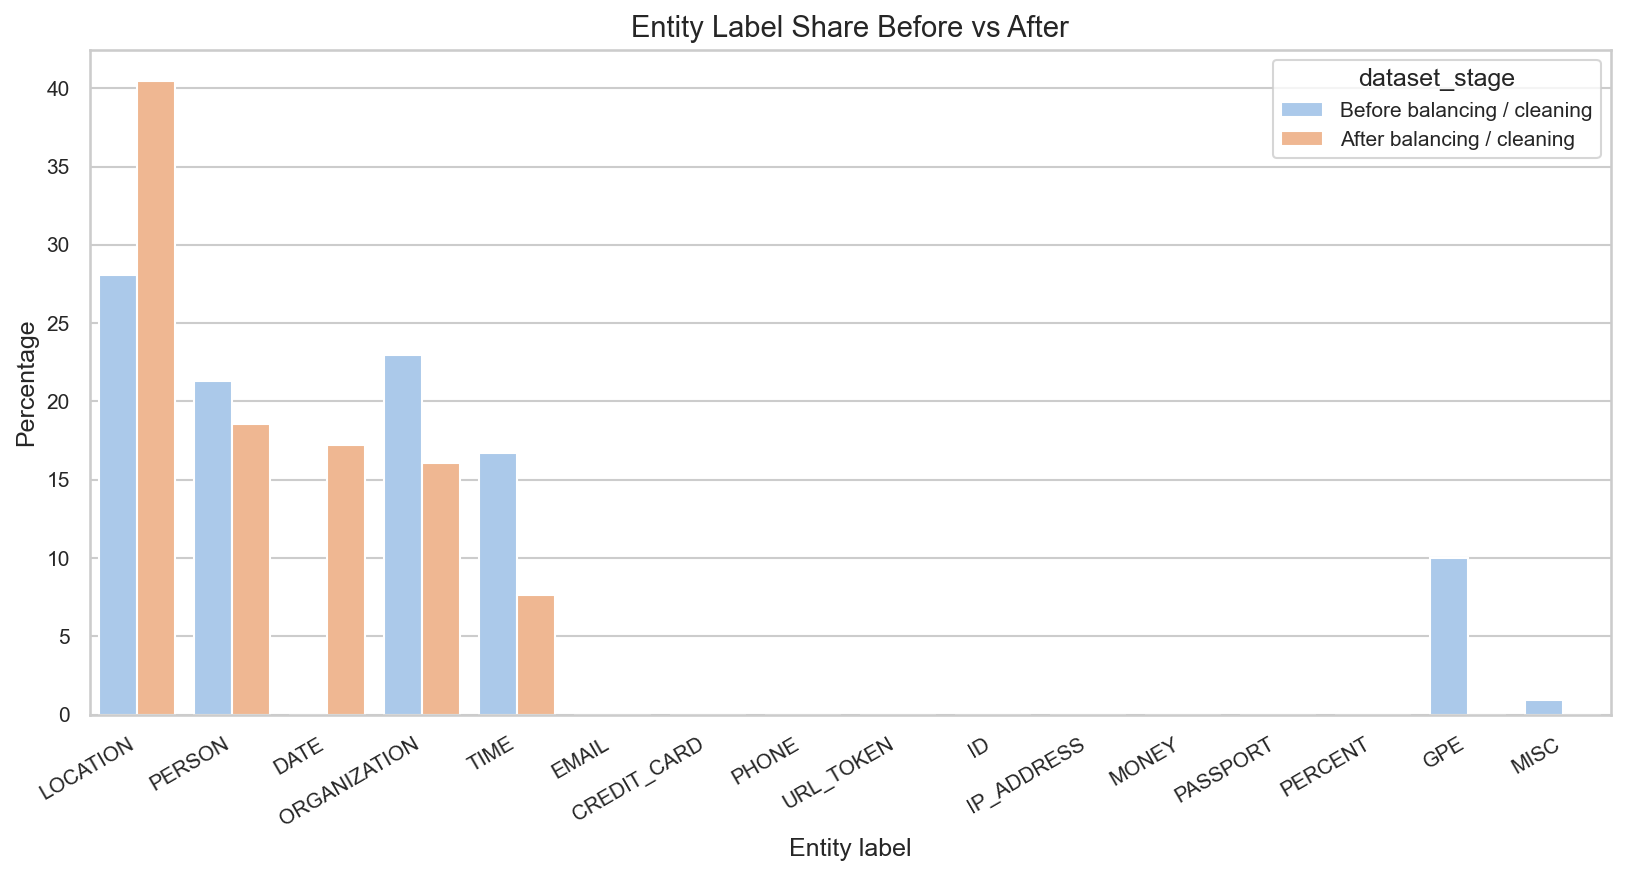

In [45]:
# =========================================
# 16. Optional percentage comparison chart
# =========================================
plot_pct_df = before_after_df.melt(
    id_vars="label",
    value_vars=["raw_pct", "cleaned_pct"],
    var_name="dataset_stage",
    value_name="percentage"
)
plot_pct_df["dataset_stage"] = plot_pct_df["dataset_stage"].map({
    "raw_pct": "Before balancing / cleaning",
    "cleaned_pct": "After balancing / cleaning",
})

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=plot_pct_df, x="label", y="percentage", hue="dataset_stage", palette=PALETTE, ax=ax)
ax.set_title("Entity Label Share Before vs After")
ax.set_xlabel("Entity label")
ax.set_ylabel("Percentage")
plt.xticks(rotation=30, ha="right")
savefig("before_vs_after_balancing_percentage.png")
plt.show()

In [46]:
# ================================
# Prepare Tag Columns (BIO Split)
# ================================

# ---- Detect tag column automatically ----
possible_tag_cols = ["Tag", "tag", "Label", "label", "NER", "ner"]
tag_col = None

for col in possible_tag_cols:
    if col in raw_df.columns:
        tag_col = col
        break

if tag_col is None:
    raise ValueError(f"No tag column found. Available columns: {list(raw_df.columns)}")

print(f"Using tag column: {tag_col}")

# ---- Create TagGeneral and TagPos ----
raw_df["TagPos"] = raw_df[tag_col].apply(
    lambda x: x.split("-")[0] if isinstance(x, str) and "-" in x else x
)

raw_df["TagGeneral"] = raw_df[tag_col].apply(
    lambda x: x.split("-")[1] if isinstance(x, str) and "-" in x else x
)

# ---- Normalize 'O' label ----
raw_df.loc[raw_df[tag_col] == "O", "TagGeneral"] = "O"
raw_df.loc[raw_df[tag_col] == "O", "TagPos"] = "O"

# ---- Quick check ----
display(raw_df[[tag_col, "TagPos", "TagGeneral"]].head())

Using tag column: Tag


,Tag,TagPos,TagGeneral
0,O,O,O
1,O,O,O
2,O,O,O
3,O,O,O
4,O,O,O


Saved to: C:\Users\lynny\OneDrive\Desktop\uni\year 4\winter2026\st DSAI4201 selected topics\project\code\smart-document-redaction\notebooks\figures\label_distribution.png


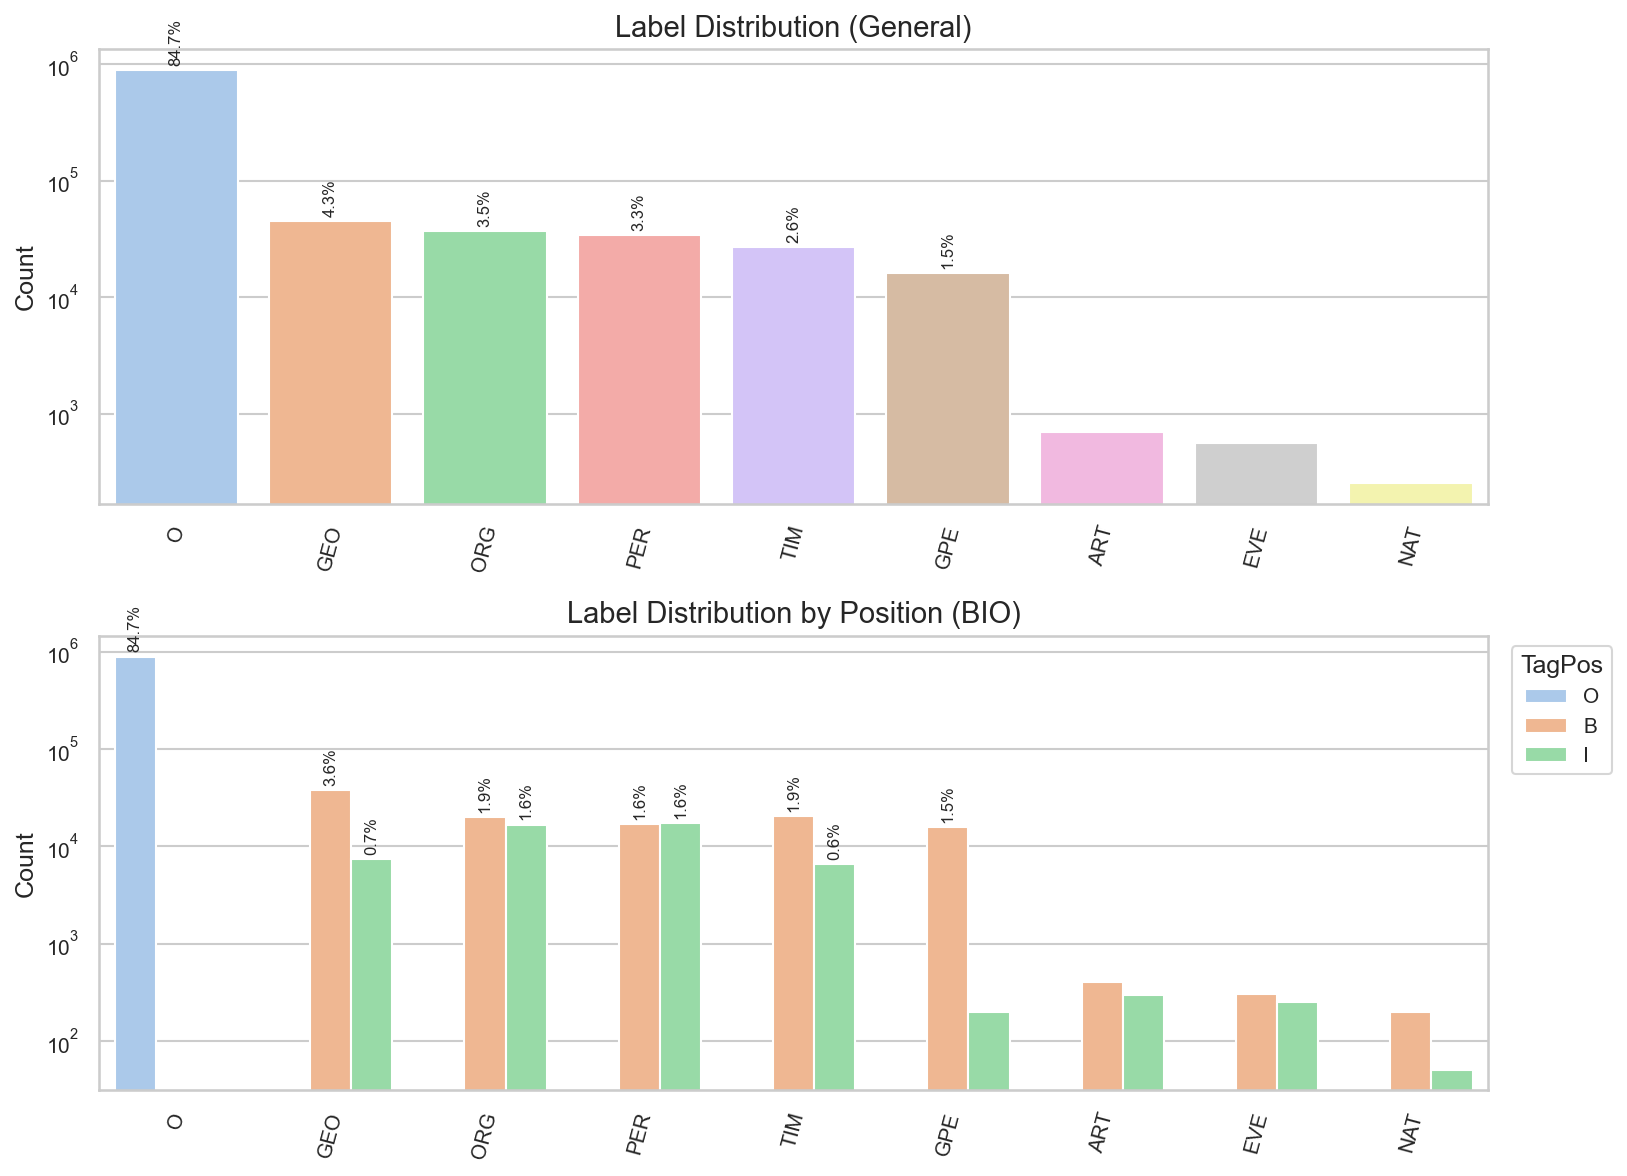

In [ ]:
# ================================
# Label Distribution Visualization
# ================================

import numpy as np

# ---- Use global FIG_DIR ----
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ---- Validate required columns ----
required_cols = ["TagGeneral", "TagPos"]
missing = [c for c in required_cols if c not in raw_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# ---- Order labels by frequency ----
order = raw_df["TagGeneral"].value_counts().index

# ---- Create figure ----
fig, axs = plt.subplots(2, 1, figsize=(11, 8))

# --- Plot 1: TagGeneral count ---
sns.countplot(
    data=raw_df,
    x="TagGeneral",
    order=order,
    ax=axs[0],
    palette=PALETTE
)

axs[0].set_title("Label Distribution (General)")
axs[0].set_xlabel("")
axs[0].set_ylabel("Count")

# --- Plot 2: TagGeneral vs TagPos ---
sns.countplot(
    data=raw_df,
    x="TagGeneral",
    hue="TagPos",
    order=order,
    ax=axs[1],
    palette=PALETTE
)

axs[1].set_title("Label Distribution by Position (BIO)")
axs[1].set_xlabel("")
axs[1].set_ylabel("Count")

# ---- Formatting ----
for ax in axs:
    ax.tick_params(axis='x', rotation=75)
    ax.set_yscale("log")

# ---- Annotate percentages ----
total = len(raw_df)

for ax in axs:
    for p in ax.patches:
        height = p.get_height()
        if height > total * 0.001:  # avoid clutter
            percentage = 100 * height / total
            ax.annotate(
                f"{percentage:.1f}%",
                (p.get_x() + p.get_width() / 2, height),
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=90,
                xytext=(0, 2),
                textcoords="offset points"
            )

# ---- Legend formatting ----
axs[1].legend(title="TagPos", bbox_to_anchor=(1.01, 1), loc="upper left")

# ---- Layout & Save ----
plt.tight_layout()

save_path = FIG_DIR / "label_distribution.png"
plt.savefig(save_path, dpi=FIG_DPI, bbox_inches="tight")

print(f"Saved to: {save_path}")

plt.show()

## Suggested report-ready interpretation snippets

- **Sentence length distribution:** Sentence lengths vary significantly, indicating diverse linguistic structures and supporting stronger model generalization.
- **Entity length distribution:** Most entities are short and concentrated in the 1–3 token range, which aligns with BIO-style tagging behavior while still preserving some multi-token complexity.
- **Top entity types:** Core entity categories dominate after cleaning/filtering, showing that the dataset is aligned with the intended redaction objectives.
- **Class imbalance:** The token-level class distribution is strongly skewed toward the non-entity class (`O`), motivating balancing, augmentation, weighted training, or stratified evaluation.
- **Before vs after balancing:** The post-processed dataset shows a more controlled label distribution, demonstrating that the preprocessing pipeline actively improved training suitability rather than merely reformatting the corpus.

In [48]:
# ============================
# 17. Final artifact manifest
# ============================
artifact_files = sorted([p.name for p in FIG_DIR.iterdir()])
manifest_df = pd.DataFrame({"saved_artifact": artifact_files})
display(manifest_df)
print(f"Total saved artifacts: {len(artifact_files)}")

,saved_artifact
0,before_vs_after_balancing.png
1,before_vs_after_balancing_percentage.png
2,before_vs_after_balancing_table.csv
3,bio_prefix_distribution.csv
4,bio_prefix_distribution.png
5,class_imbalance_ratio_table.csv
6,cleaned_entity_type_distribution.csv
7,dataset_summary.csv
8,entities_per_sentence.png
9,entities_per_sentence_table.csv


Total saved artifacts: 18
